In [1]:
'''
Author: zhangshd
Date: 2025-05-16
Description: Example Jupyter notebook demonstrating interactive visualization of atom importance
'''
%load_ext autoreload
%autoreload 2
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
ROOT_DIR = Path(".").resolve().parent
sys.path.append(str(ROOT_DIR))

# Import necessary modules
from src.cgcnn.visualization.atom_visualizer import AtomImportanceVisualizer
from src.cgcnn.module.att_cgcnn import CrystalGraphConvNet
from src.cgcnn.inference import InferenceDataset
from src.cgcnn.utils import load_model_from_dir
import traceback
import ipywidgets as widgets
from IPython.display import display

# Set matplotlib to show plots inline
%matplotlib inline

In [5]:
# Introduction
print("# Interactive Atom Importance Visualization Demo")
print("This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.")
print("\n## 1. Load Model and Dataset")

# Load model
model_path = ROOT_DIR/'results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43'
model_checkpoint = list(model_path.glob('*/best*.ckpt'))[0]
print(f"Loading model from: {model_checkpoint}")

def load_model(checkpoint_path):
    """Load a trained CrystalGraphConvNet model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
    
    # Initialize model
    model = CrystalGraphConvNet(**checkpoint["hyper_parameters"])
    
    # Load state dict
    model.load_state_dict({k.replace("model.", ""):v for k,v in checkpoint['state_dict'].items()})
    model.eval()
    
    return model

try:
    # model = load_model(model_checkpoint)
    model, trainer = load_model_from_dir(model_path, accelerator="cpu")
    model = model.model
    print(f"Model loaded successfully")
    print(f"Task types: {model.kwargs['task_types']}")
    print(f"Using attention pooling: {model.kwargs['att_pooling']}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please update the path to your trained model and try again")

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


# Interactive Atom Importance Visualization Demo
This notebook demonstrates how to use NGLView for interactive visualization of atom importance in MOF structures.

## 1. Load Model and Dataset
Loading model from: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
task_types:  ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']
Loading the best model checkpoint: /home/zhangsd/repos/MOFSNN/results/cgcnn_models/TSD_SSD_WS24_water_WS24_water4_WS24_acid_WS24_base_WS24_boiling_seed42_att_cgcnn/version_43/checkpoints/best-epoch=108-val_Metric=0.608.ckpt
Model loaded successfully
Task types: ['regression', 'classification', 'classification', 'classification_4', 'classification', 'classification', 'classification']
Using attention pooling: False


In [6]:
# Load example CIF file
print("\n## 2. Load MOF Structure")
cif_dir = ROOT_DIR/'data/example_cifs'
print(f"Looking for CIF files in: {cif_dir}")
cif_files = list(cif_dir.glob('*.cif'))

# Select a CIF file
# cif_path = str(cif_files[0])
# cif_path = ROOT_DIR/'data/example_cifs/CALF20.cif'
cif_path = ROOT_DIR/'data/example_cifs/Cu-BTC.cif'
print(f"Using CIF file: {cif_path}")

# Create inference dataset
def load_dataset(cif_path):
    """Load data from a CIF file"""
    temp_dir = Path('./temp_inference')
    temp_dir.mkdir(exist_ok=True)
    
    dataset = InferenceDataset(
        [cif_path], 
        saved_dir=temp_dir,
        **{k:v for k,v in model.kwargs.items() if k not in ["saved_dir"]},
    )
    
    dataset.setup()
    return dataset

dataset = load_dataset(cif_path)
print(f"CIF data loaded successfully")


## 2. Load MOF Structure
Looking for CIF files in: /home/zhangsd/repos/MOFSNN/data/example_cifs
Using CIF file: /home/zhangsd/repos/MOFSNN/data/example_cifs/Cu-BTC.cif
CIF data loaded successfully


In [7]:
# Process data
print("\n## 3. Prepare Data for Visualization")

# Get data for the structure
data_dict = dataset[0]
atom_fea = data_dict["atom_fea"] 
nbr_fea = data_dict["nbr_fea"]
nbr_fea_idx = data_dict["nbr_fea_idx"]
extra_fea = data_dict["extra_fea"]
cif_id = data_dict["cif_id"]

# Get atom coordinates and elements
from ase.io import read
structure = read(cif_path)
atom_coords = structure.get_positions()
atom_elements = structure.get_chemical_symbols()

# Process into a batch
data_batch = dataset.collate([data_dict])
atom_fea_batch = data_batch["atom_fea"]
nbr_fea_batch = data_batch["nbr_fea"]
nbr_fea_idx_batch = data_batch["nbr_fea_idx"]
crystal_atom_idx_batch = data_batch["crystal_atom_idx"]



## 3. Prepare Data for Visualization


In [9]:
# Create visualizer

visualizer = AtomImportanceVisualizer(model)

print("\n## 4. Calculate Atom Importance")
# Calculate atom importance for all tasks
task_results = {}
for task_idx in range(len(model.task_types)):
    result = visualizer.calculate_atom_importance(
        atom_fea_batch, nbr_fea_batch, nbr_fea_idx_batch, crystal_atom_idx_batch,
        extra_fea=data_batch["extra_fea"], task_idx=task_idx, return_gradients=False,
        method='guided_grad_cam',
    )
    print(f"Task {task_idx} ({model.task_types[task_idx]}):")
    print(f"  Atom importance shape: {result['atom_importance'][0].shape}")
    task_results[task_idx] = result['atom_importance'][0]
    
# Print summary of atom importance scores for each task
print("\nAtom Importance Summary:")
for task_idx, importance in task_results.items():
    print(f"Task {task_idx} ({model.task_types[task_idx]}): mean={np.mean(importance):.4f}, max={np.max(importance):.4f}")



## 4. Calculate Atom Importance
Predicted output [guided_grad_cam]: tensor([[-0.7636]], grad_fn=<AddmmBackward0>)
Task 0 (regression):
  Atom importance shape: (624,)
Predicted output [guided_grad_cam]: tensor([[-1.0446e+01, -2.9087e-05]], grad_fn=<LogSoftmaxBackward0>)
Task 1 (classification):
  Atom importance shape: (624,)
Predicted output [guided_grad_cam]: tensor([[-3.6499, -0.0263]], grad_fn=<LogSoftmaxBackward0>)
Task 2 (classification):
  Atom importance shape: (624,)
Predicted output [guided_grad_cam]: tensor([[-6.7167, -1.5257, -0.6407, -1.3688]], grad_fn=<LogSoftmaxBackward0>)
Task 3 (classification_4):
  Atom importance shape: (624,)
Predicted output [guided_grad_cam]: tensor([[-3.9673e-03, -5.5316e+00]], grad_fn=<LogSoftmaxBackward0>)
Task 4 (classification):
  Atom importance shape: (624,)
Predicted output [guided_grad_cam]: tensor([[-4.3429e-03, -5.4414e+00]], grad_fn=<LogSoftmaxBackward0>)
Task 5 (classification):
  Atom importance shape: (624,)
Predicted output [guide

In [10]:
# Analysis of top important atoms
print("\n## 8. Identify and Analyze Top Important Atoms")
# Number of top atoms to analyze
top_n = 10

for task_idx in range(len(model.task_types)):
    importance = task_results[task_idx]
    top_indices = np.argsort(-np.abs(importance))[:top_n]  # Sort by descending importance
    
    print(f"\nTask {task_idx} ({model.task_types[task_idx]})")
    print(f"Top {top_n} most important atoms:")
    for i, idx in enumerate(top_indices):
        element = atom_elements[idx]
        score = importance[idx]
        coords = atom_coords[idx]
        print(f"  {i+1}. {element} (atom {idx}): score = {score:.4f}, coordinates = [{coords[0]:.2f}, {coords[1]:.2f}, {coords[2]:.2f}]")
        
    # Analyze element types in top atoms
    top_elements = [atom_elements[idx] for idx in top_indices]
    element_counts = {}
    for elem in top_elements:
        element_counts[elem] = element_counts.get(elem, 0) + 1
    
    print(f"  Element distribution in top {top_n} atoms:")
    for elem, count in element_counts.items():
        print(f"    {elem}: {count} atoms ({count/top_n*100:.1f}%)")


## 8. Identify and Analyze Top Important Atoms

Task 0 (regression)
Top 10 most important atoms:
  1. Cu (atom 210): score = 0.9999, coordinates = [0.00, 5.66, 20.69]
  2. C (atom 260): score = 0.9999, coordinates = [24.53, 5.35, 18.52]
  3. C (atom 258): score = 0.9999, coordinates = [18.52, 1.81, 20.99]
  4. O (atom 56): score = 0.9999, coordinates = [6.40, 11.80, 21.51]
  5. O (atom 58): score = 0.9999, coordinates = [6.40, 14.55, 4.83]
  6. O (atom 61): score = 0.9999, coordinates = [19.94, 4.83, 14.55]
  7. O (atom 64): score = 0.9999, coordinates = [8.34, 11.80, 6.77]
  8. O (atom 65): score = 0.9999, coordinates = [18.00, 11.80, 19.58]
  9. O (atom 67): score = 0.9999, coordinates = [8.34, 14.55, 19.58]
  10. O (atom 71): score = 0.9999, coordinates = [1.38, 6.77, 4.83]
  Element distribution in top 10 atoms:
    Cu: 1 atoms (10.0%)
    C: 2 atoms (20.0%)
    O: 7 atoms (70.0%)

Task 1 (classification)
Top 10 most important atoms:
  1. C (atom 439): score = 0.0009, coordinates 


## 5. Static Matplotlib Visualization

## 6. Interactive NGLView Visualization
NGLView is available. Creating interactive visualization...
Important atoms with high contribution values:
  O (atom 56): 1.000
  O (atom 57): 1.000
  O (atom 58): 1.000
  O (atom 59): 1.000
  O (atom 60): 1.000
  O (atom 61): 1.000
  O (atom 62): 1.000
  O (atom 63): 1.000
  O (atom 64): 1.000
  O (atom 65): 1.000
  O (atom 66): 1.000
  O (atom 67): 1.000
  O (atom 68): 1.000
  O (atom 69): 1.000
  O (atom 70): 1.000
  O (atom 71): 1.000
  O (atom 104): 1.000
  O (atom 105): 1.000
  O (atom 106): 1.000
  O (atom 107): 1.000
  O (atom 108): 1.000
  O (atom 109): 1.000
  O (atom 110): 1.000
  O (atom 111): 1.000
  Cu (atom 208): 1.000
  Cu (atom 209): 1.000
  Cu (atom 210): 1.000
  Cu (atom 211): 1.000
  Cu (atom 212): 1.000
  Cu (atom 213): 1.000
  Cu (atom 214): 1.000
  Cu (atom 215): 1.000
  C (atom 248): 1.000
  C (atom 249): 1.000
  C (atom 250): 1.000
  C (atom 251): 1.000
  C (atom 252): 1.000
  C (at

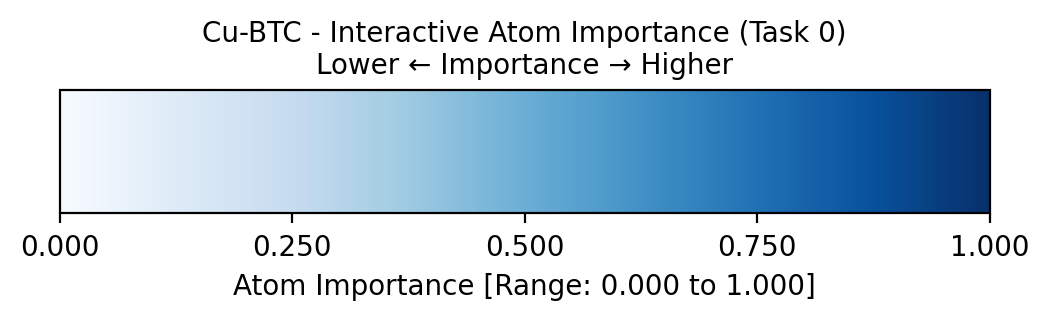

Visualization: Cu-BTC - Interactive Atom Importance (Task 0)
Total atoms: 624
Importance range: [0.000, 1.000]
Color mapping range: [0.000, 1.000]
Atoms above importance threshold (0.70): 96

Interactive visualization controls:
- Left mouse: Rotate
- Right mouse: Zoom
- Middle mouse: Pan
- Double-click: Center on atom

## 7. Multi-task Comparison
Creating interactive comparison of tasks...
Comparison visualization using consistent color scale: [-1.000, 1.000]
Error creating combined visualization: Traceback (most recent call last):
  File "/home/zhangsd/repos/MOFSNN/src/cgcnn/visualization/ngl_visualizer.py", line 450, in visualize_comparison
    component = main_view.add_component(atoms_copy)
  File "/opt/share/miniconda3/envs/mofmthnn/lib/python3.9/site-packages/nglview/widget.py", line 1115, in add_component
    self._load_data(filename, **kwargs)
  File "/opt/share/miniconda3/envs/mofmthnn/lib/python3.9/site-packages/nglview/widget.py", line 1141, in _load_data
    blob = obj.get_s

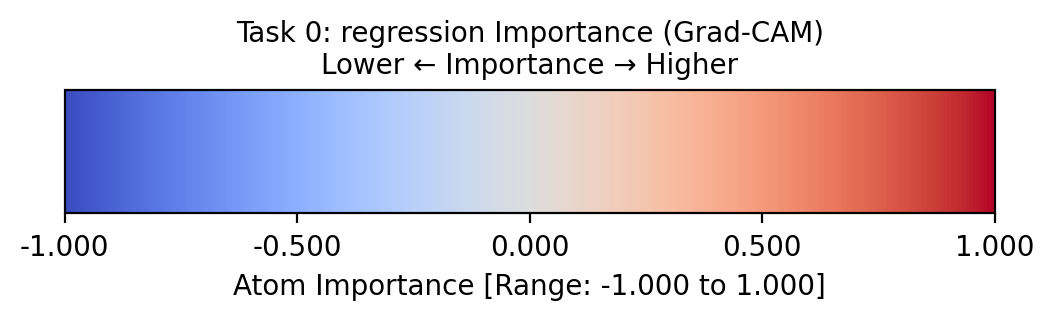

Visualization: Task 0: regression Importance (Grad-CAM)
Total atoms: 624
Importance range: [0.000, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 96
Important atoms with high contribution values:
  O (atom 24): 0.001
  O (atom 25): 0.001
  O (atom 26): 0.001
  O (atom 27): 0.001
  O (atom 28): 0.001
  O (atom 29): 0.001
  O (atom 30): 0.001
  O (atom 31): 0.001
  O (atom 112): 0.001
  O (atom 113): 0.001
  O (atom 114): 0.001
  O (atom 115): 0.001
  O (atom 116): 0.001
  O (atom 117): 0.001
  O (atom 118): 0.001
  O (atom 119): 0.001
  O (atom 120): 0.001
  O (atom 121): 0.001
  O (atom 122): 0.001
  O (atom 123): 0.001
  O (atom 124): 0.001
  O (atom 125): 0.001
  O (atom 126): 0.001
  O (atom 127): 0.001
  Cu (atom 192): 0.001
  Cu (atom 193): 0.001
  Cu (atom 194): 0.001
  Cu (atom 195): 0.001
  Cu (atom 196): 0.001
  Cu (atom 197): 0.001
  Cu (atom 198): 0.001
  Cu (atom 199): 0.001
  Cu (atom 200): 0.001
  Cu (atom 201): 0.001
  Cu (atom 202):

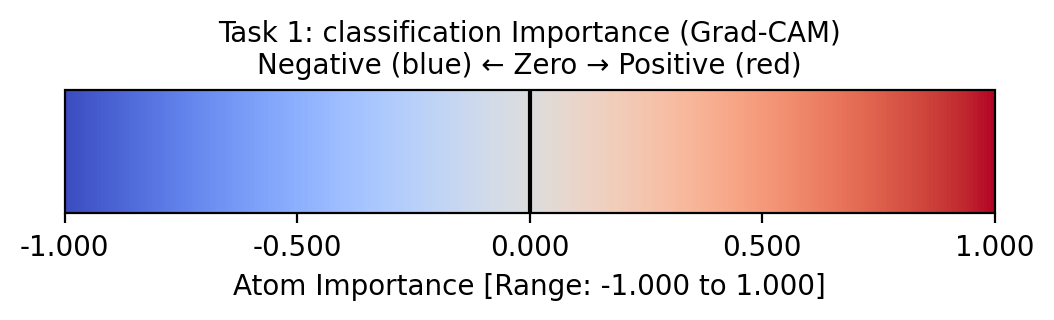

Visualization: Task 1: classification Importance (Grad-CAM)
Total atoms: 624
Importance range: [-0.000, 0.001]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 96
Important atoms with high contribution values:
  O (atom 0): 0.999
  O (atom 1): 0.999
  O (atom 2): 0.999
  O (atom 3): 0.999
  O (atom 4): 0.999
  O (atom 5): 0.999
  O (atom 6): 0.999
  O (atom 7): 0.999
  O (atom 128): 0.999
  O (atom 129): 0.999
  O (atom 130): 0.999
  O (atom 131): 0.999
  O (atom 132): 0.999
  O (atom 133): 0.999
  O (atom 134): 0.999
  O (atom 135): 0.999
  O (atom 184): 0.999
  O (atom 185): 0.999
  O (atom 186): 0.999
  O (atom 187): 0.999
  O (atom 188): 0.999
  O (atom 189): 0.999
  O (atom 190): 0.999
  O (atom 191): 0.999
  C (atom 312): 0.999
  C (atom 313): 0.999
  C (atom 314): 0.999
  C (atom 315): 0.999
  C (atom 316): 0.999
  C (atom 317): 0.999
  C (atom 318): 0.999
  C (atom 319): 0.999
  C (atom 440): 0.999
  C (atom 441): 0.999
  C (atom 442): 0.999
  C (at

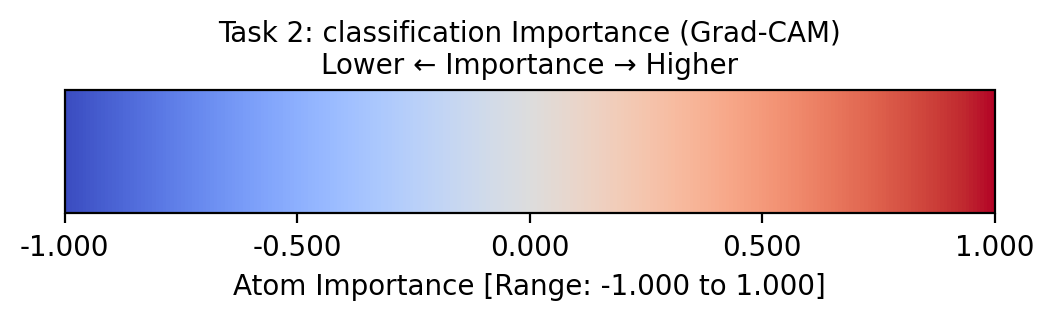

Visualization: Task 2: classification Importance (Grad-CAM)
Total atoms: 624
Importance range: [0.045, 0.999]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 48
Important atoms with high contribution values:
  O (atom 24): 1.000
  O (atom 25): 1.000
  O (atom 26): 1.000
  O (atom 27): 1.000
  O (atom 28): 1.000
  O (atom 29): 1.000
  O (atom 30): 1.000
  O (atom 31): 1.000
  O (atom 112): 1.000
  O (atom 113): 1.000
  O (atom 114): 1.000
  O (atom 115): 1.000
  O (atom 116): 1.000
  O (atom 117): 1.000
  O (atom 118): 1.000
  O (atom 119): 1.000
  O (atom 120): 1.000
  O (atom 121): 1.000
  O (atom 122): 1.000
  O (atom 123): 1.000
  O (atom 124): 1.000
  O (atom 125): 1.000
  O (atom 126): 1.000
  O (atom 127): 1.000
  Cu (atom 192): 1.000
  Cu (atom 193): 1.000
  Cu (atom 194): 1.000
  Cu (atom 195): 1.000
  Cu (atom 196): 1.000
  Cu (atom 197): 1.000
  Cu (atom 198): 1.000
  Cu (atom 199): 1.000
  Cu (atom 200): 1.000
  Cu (atom 201): 1.000
  Cu (atom 2

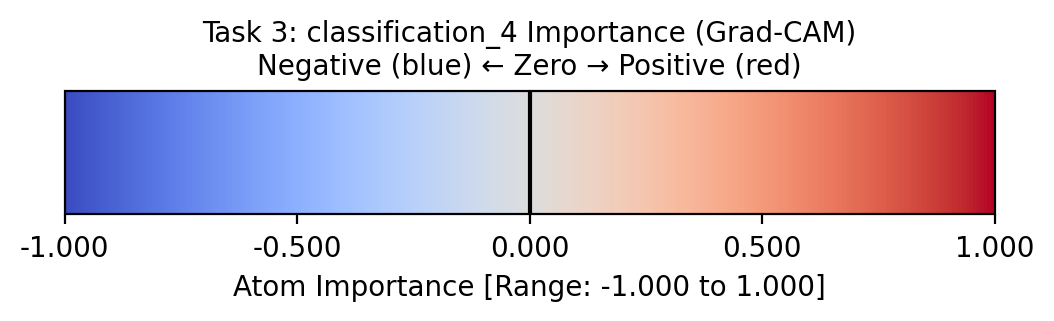

Visualization: Task 3: classification_4 Importance (Grad-CAM)
Total atoms: 624
Importance range: [-0.064, 1.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 96
Important atoms with high contribution values:
  O (atom 8): -0.914
  O (atom 9): -0.953
  O (atom 10): -0.874
  O (atom 11): -0.874
  O (atom 12): -0.953
  O (atom 13): -0.914
  O (atom 14): -0.874
  O (atom 15): -0.874
  O (atom 16): -0.914
  O (atom 17): -0.874
  O (atom 18): -0.874
  O (atom 19): -0.914
  O (atom 20): -0.874
  O (atom 21): -0.874
  O (atom 22): -0.914
  O (atom 23): -0.953
  O (atom 88): -0.914
  O (atom 89): -0.913
  O (atom 90): -0.953
  O (atom 91): -0.874
  O (atom 92): -0.914
  O (atom 93): -0.953
  O (atom 94): -0.913
  O (atom 95): -0.913
  O (atom 96): -0.914
  O (atom 97): -0.874
  O (atom 98): -0.874
  O (atom 99): -0.913
  O (atom 100): -0.913
  O (atom 101): -0.874
  O (atom 102): -0.914
  O (atom 103): -0.874
  O (atom 144): -0.874
  O (atom 145): -0.914
  O (at

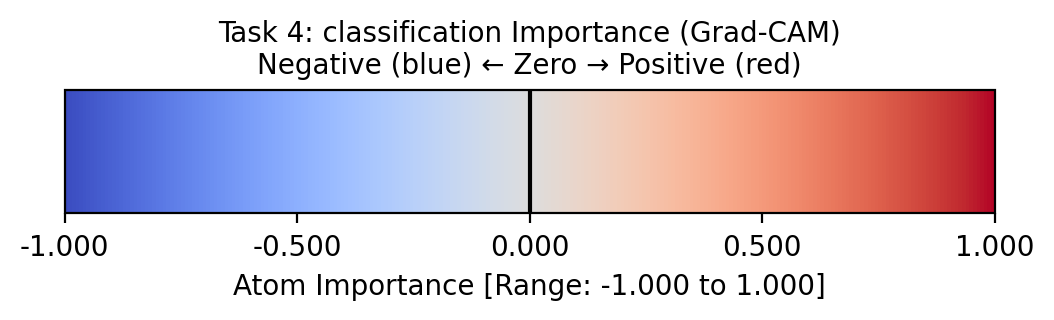

Visualization: Task 4: classification Importance (Grad-CAM)
Total atoms: 624
Importance range: [-0.953, -0.024]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 192
Important atoms with high contribution values:
  O (atom 8): -0.894
  O (atom 9): -0.960
  O (atom 10): -0.839
  O (atom 11): -0.839
  O (atom 12): -0.960
  O (atom 13): -0.894
  O (atom 14): -0.839
  O (atom 15): -0.839
  O (atom 16): -0.894
  O (atom 17): -0.839
  O (atom 18): -0.839
  O (atom 19): -0.894
  O (atom 20): -0.839
  O (atom 21): -0.839
  O (atom 22): -0.894
  O (atom 23): -0.960
  O (atom 88): -0.894
  O (atom 89): -0.906
  O (atom 90): -0.960
  O (atom 91): -0.839
  O (atom 92): -0.894
  O (atom 93): -0.960
  O (atom 94): -0.906
  O (atom 95): -0.906
  O (atom 96): -0.894
  O (atom 97): -0.839
  O (atom 98): -0.839
  O (atom 99): -0.906
  O (atom 100): -0.906
  O (atom 101): -0.839
  O (atom 102): -0.894
  O (atom 103): -0.839
  O (atom 144): -0.839
  O (atom 145): -0.894
  O (at

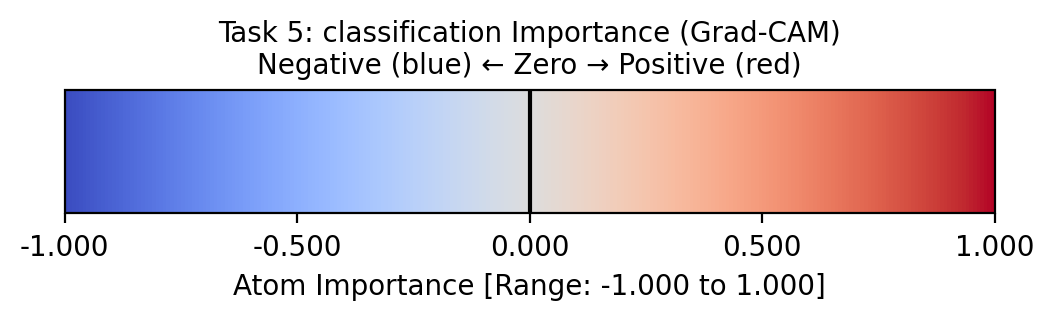

Visualization: Task 5: classification Importance (Grad-CAM)
Total atoms: 624
Importance range: [-0.960, 0.000]
Color mapping range: [-1.000, 1.000]
Atoms above importance threshold (0.70): 192


In [ ]:

# Static Visualization
print("\n## 5. Static Matplotlib Visualization")
# Choose a task to visualize
task_idx = 0  # Change this to visualize different tasks

# Visualization parameters
figsize = (12, 10)
colormap = 'Blues'
highlight_threshold = 0.7

# # Check dimensions and ensure they match
# print(f"Atom coordinates shape: {atom_coords.shape}")
# print(f"Importance scores shape: {task_results[task_idx].shape}")
# print(f"Number of atom elements: {len(atom_elements)}")

# # Ensure all arrays have the same length
# min_length = min(len(atom_coords), len(task_results[task_idx]), len(atom_elements))
# atom_coords_vis = atom_coords[:min_length]
# importance_vis = task_results[task_idx][:min_length]
# atom_elements_vis = atom_elements[:min_length]

# print(f"Using {min_length} atoms for visualization")

# # Visualize atom importance for the selected task
# fig, ax = visualizer.visualize_atom_importance(
#     atom_coords_vis, importance_vis, 
#     atom_elements=atom_elements_vis,
#     figsize=figsize,
#     colormap=colormap,
#     title=f"{cif_id} - Atom Importance for Task {task_idx} ({model.task_types[task_idx]})",
#     highlight_threshold=highlight_threshold
# )

# plt.tight_layout()
# plt.show()

# Interactive Visualization
print("\n## 6. Interactive NGLView Visualization")
try:
    # Check if NGLView is available
    import nglview
    print("NGLView is available. Creating interactive visualization...")
    
    # Create an interactive visualization using NGLView
    ngl_view = visualizer.visualize_atom_importance(
        atoms=structure,
        atom_importance=task_results[task_idx],
        atom_elements=atom_elements,
        title=f"{cif_id} - Interactive Atom Importance (Task {task_idx})",
        colormap=colormap,
        highlight_threshold=highlight_threshold
    )
    
    if ngl_view is not None:
        print("\nInteractive visualization controls:")
        print("- Left mouse: Rotate")
        print("- Right mouse: Zoom")
        print("- Middle mouse: Pan")
        print("- Double-click: Center on atom")
    else:
        print("Failed to create NGLView visualization.")
except ImportError:
    print("NGLView is not installed. To enable interactive visualization, install it with:")
    print("pip install nglview")
except Exception as e:
    traceback.print_exc()


# Multi-task comparison (if multiple tasks available)
if len(model.task_types) > 1:
    print("\n## 7. Multi-task Comparison")
    try:
        import nglview
        print("Creating interactive comparison of tasks...")
        
        # Create a dictionary of task names and importance scores
        task_importance_dict = {}
        for idx, task_type in enumerate(model.task_types):
            task_importance_dict[f"Task {idx}: {task_type}"] = task_results[idx]
        
        # Create multi-task visualization with the simplified API
        views = visualizer.compare_task_importance(
            atoms=structure,
            task_importances=task_importance_dict,
            atom_elements=atom_elements,
            highlight_threshold=highlight_threshold,
            combined_view=True
        )
        
        if views is not None:
            print(f"Created {len(views)} interactive visualizations for comparison.")
        else:
            print("Failed to create comparison visualizations.")
    except ImportError:
        print("NGLView is not installed. Multi-task comparison requires NGLView.")


print("\n## 10. Conclusion")
print("This notebook demonstrated how to visualize atom importance using:")
print("1. Interactive 3D visualization with NGLView")
print("\nThese visualizations help interpret which atoms most influence the model's predictions.")
print("The gradient-based importance calculation works even for models without attention mechanisms.")

In [ ]:
ngl_view

In [17]:
views

{'Task 0: regression': NGLWidget(),
 'Task 1: classification': NGLWidget(),
 'Task 2: classification': NGLWidget(),
 'Task 3: classification_4': NGLWidget(),
 'Task 4: classification': NGLWidget(),
 'Task 5: classification': NGLWidget(),
 'Task 6: classification': NGLWidget()}

In [31]:
list(views.keys())

['Task 0: regression',
 'Task 1: classification',
 'Task 2: classification',
 'Task 3: classification_4',
 'Task 4: classification',
 'Task 5: classification',
 'Task 6: classification']

In [20]:
views[list(views.keys())[1]]

NGLWidget(n_components=1)

In [20]:
# Export the visualization to HTML
print("\n## 9. Export Visualization to HTML")

# Check if we have a valid NGLView object
if 'ngl_view' in locals() and ngl_view is not None:
    
    # Generate HTML representation
    output_path = "mof_atom_importance_visualization.html"
    
    # Generate HTML content
    # html_content = ngl_view.write(output_path)
    nglview.write_html(output_path, ngl_view)
    # Save to file
    # with open(output_path, "w") as f:
    #     f.write(html_content)
    
    print(f"Visualization saved to: {output_path}")
    print("You can open this HTML file in any web browser to view the 3D structure.")
    print("Note: Some advanced interactive features may not work in the exported HTML.")
else:
    print("No valid NGLView object available to export.")


## 9. Export Visualization to HTML
Visualization saved to: mof_atom_importance_visualization.html
You can open this HTML file in any web browser to view the 3D structure.
Note: Some advanced interactive features may not work in the exported HTML.


In [13]:
import nglview